# Phase 07.1 — Density-Stratified Null and Seed Stability

Renders the 07.1 record (`notebooks/.cache/07.1_density_stratified_null.jsonl`, 34 rows) and
Phase 7's frozen record (`notebooks/.cache/07_crossmodal_curvature.jsonl`) for comparison. This
notebook **reads the frozen record; it does not recompute the stratified null, refit any decoder,
or reimplement any statistic.** Full prose and every table's provenance: `07.1-FINDINGS.md`.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

RECORD_PATH = ".cache/07.1_density_stratified_null.jsonl"
PHASE7_RECORD_PATH = ".cache/07_crossmodal_curvature.jsonl"
SEED_FIELDS_PATH = ".cache/07.1_seed_fields_d25.npz"

def load_jsonl(path):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

rows = load_jsonl(RECORD_PATH)
phase7_rows = load_jsonl(PHASE7_RECORD_PATH)

by_kind = {}
for r in rows:
    by_kind.setdefault(r["row_kind"], []).append(r)

null_grid = by_kind["null_grid"]
null_mean_vs_strata = by_kind["null_mean_vs_strata"][0]
positive_control = by_kind["positive_control"]
positive_control_summary = by_kind["positive_control_summary"][0]
verdict_row = by_kind["verdict"][0]
seed_rows = by_kind["seed"]
seed_verdict_row = by_kind["seed_verdict"][0]

phase7_sweep = {r["d"]: r for r in phase7_rows if r.get("row_kind") == "sweep"}

print(f"07.1 record: {len(rows)} rows, row_kinds: "
      f"{ {k: len(v) for k, v in by_kind.items()} }")
print(f"Phase 7 record: {len(phase7_rows)} rows, {len(phase7_sweep)} sweep rows (d={sorted(phase7_sweep)})")


07.1 record: 34 rows, row_kinds: {'positive_control': 18, 'positive_control_summary': 1, 'null_grid': 9, 'null_mean_vs_strata': 1, 'verdict': 1, 'seed': 3, 'seed_verdict': 1}
Phase 7 record: 8 rows, 3 sweep rows (d=[20, 25, 32])


## D7.1-01 — per-`d` clearance table (headline `S=20`)

Reported unconditionally regardless of which verdict fired (D-15). Phase 7's borrowed
raw-statistic negative-tail threshold is shown beside 07.1's own-side band edge for contrast
only — the widening at every `d` is scoped to the partial statistic's own calibration and does
not revoke Phase 7's `ASSOCIATION DETECTED` reading of the raw statistic.

In [2]:
headline_rows = [r for r in null_grid if r["n_strata"] == 20]
headline_rows = sorted(headline_rows, key=lambda r: r["d"])

table_rows = []
for r in headline_rows:
    d = r["d"]
    table_rows.append({
        "d": d,
        "observed": r["observed"],
        "own_side_band_edge": r["own_edge"],
        "signed_margin": r["signed_margin"],
        "margin_fraction_pct": r["margin_fraction"] * 100.0,
        "clears": r["clears_either"],
        "phase7_borrowed_neg_tail_threshold": phase7_sweep[d]["negative_tail_threshold"],
    })

per_d_table = pd.DataFrame(table_rows).set_index("d")
per_d_table


,observed,own_side_band_edge,signed_margin,margin_fraction_pct,clears,phase7_borrowed_neg_tail_threshold
d,,,,,,
20,-0.024189,-0.027944,0.003755,20.187479,False,0.020624
25,-0.065835,-0.021881,-0.043954,-234.291642,True,0.019683
32,-0.021719,-0.030537,0.008819,46.646398,False,0.018728


## Null band vs. observed value, per `d` (headline `S=20`)

The record stores the null distribution's summary (`null_mean`, `null_low`, `null_high`), not
the raw resample array, so the band is rendered as its own two-tailed quantile edges rather than
a full histogram.

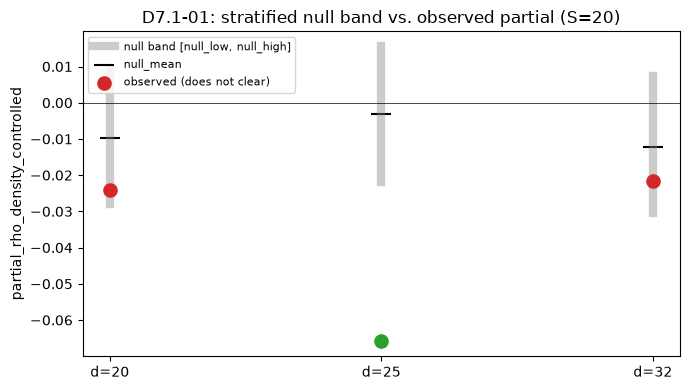

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
xs = np.arange(len(headline_rows))
for i, r in enumerate(headline_rows):
    ax.plot([i, i], [r["null_low"], r["null_high"]], color="gray", lw=6, alpha=0.4,
            label="null band [null_low, null_high]" if i == 0 else None)
    ax.scatter([i], [r["null_mean"]], color="black", marker="_", s=200,
               label="null_mean" if i == 0 else None)
    color = "tab:green" if r["clears_either"] else "tab:red"
    ax.scatter([i], [r["observed"]], color=color, s=90, zorder=5,
               label="observed (clears)" if (i == 0 and r["clears_either"]) else
                     ("observed (does not clear)" if i == 0 else None))
ax.axhline(0.0, color="black", lw=0.5)
ax.set_xticks(xs)
ax.set_xticklabels([f"d={r['d']}" for r in headline_rows])
ax.set_ylabel("partial_rho_density_controlled")
ax.set_title("D7.1-01: stratified null band vs. observed partial (S=20)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## The stratum-count grid — `null_mean` vs. `S`

`07.1-RESEARCH.md` Pitfall 1 predicted, on a synthetic fixture, a strongly POSITIVE `null_mean` at
`S=10` (+0.033) decaying toward +0.007-0.012 by `S=100-500`. The measured PU `null_mean` is
annotated against that synthetic prediction below.

In [4]:
strata_records = []
for d_str, by_s in null_mean_vs_strata["null_mean_by_d_s"].items():
    for s_str, cell in by_s.items():
        strata_records.append({
            "d": int(d_str), "S": int(s_str),
            "null_mean": cell["null_mean"], "null_std": cell["null_std"],
            "clears_either": cell["clears_either"],
        })
strata_df = pd.DataFrame(strata_records).sort_values(["d", "S"]).reset_index(drop=True)
strata_df


,d,S,null_mean,null_std,clears_either
0,20,10,-0.007970,0.009910,False
1,20,20,-0.009600,0.009692,False
2,20,50,-0.009657,0.009654,False
3,25,10,-0.001549,0.010126,True
4,25,20,-0.003022,0.009962,True
5,25,50,-0.002045,0.009736,True
6,32,10,-0.008467,0.010168,False
7,32,20,-0.012178,0.009798,False
8,32,50,-0.011790,0.009888,False


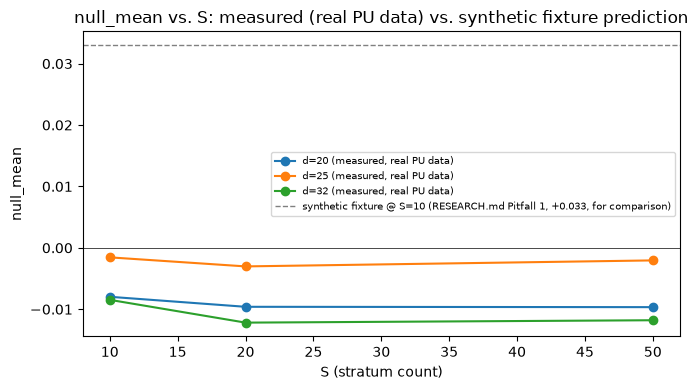

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for d in sorted(strata_df["d"].unique()):
    sub = strata_df[strata_df["d"] == d].sort_values("S")
    ax.plot(sub["S"], sub["null_mean"], marker="o", label=f"d={d} (measured, real PU data)")

# Synthetic fixture's measured trend from 07.1-RESEARCH.md Pitfall 1, annotated for comparison
# only -- not recomputed here, quoted from RESEARCH.md's own reported figures.
synthetic_S = [10, 20, 50, 100, 500]
synthetic_null_mean_hi = [0.0342, None, None, 0.012, 0.007]
ax.axhline(0.033, color="gray", ls="--", lw=1,
           label="synthetic fixture @ S=10 (RESEARCH.md Pitfall 1, +0.033, for comparison)")
ax.axhline(0.0, color="black", lw=0.5)
ax.set_xlabel("S (stratum count)")
ax.set_ylabel("null_mean")
ax.set_title("null_mean vs. S: measured (real PU data) vs. synthetic fixture prediction")
ax.legend(loc="best", fontsize=7)
plt.tight_layout()
plt.show()


## The positive control — recovery curve

Direction-matched bisection (D-04) against the frozen target grid. `smallest_cleared_target` is
marked; every point at or above it clears in that direction.

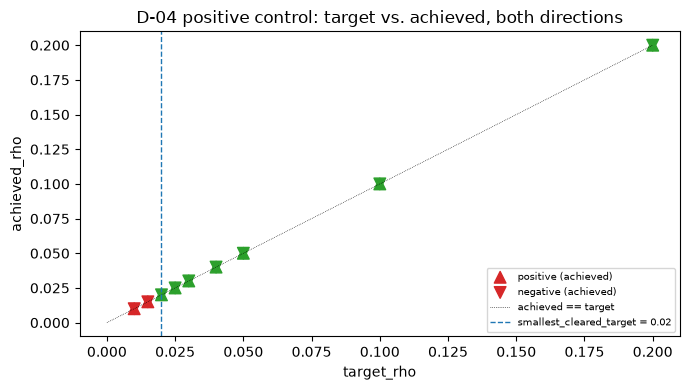

,target_rho,direction,achieved_rho,clears_either
0,0.010,negative,0.010014,False
1,0.015,negative,0.015006,False
2,0.020,negative,0.020042,True
3,0.025,negative,0.025015,True
4,0.030,negative,0.030058,True
5,0.040,negative,0.040040,True
6,0.050,negative,0.050014,True
7,0.100,negative,0.100012,True
8,0.200,negative,0.200005,True
9,0.010,positive,0.010014,False


In [6]:
pc_df = pd.DataFrame(positive_control)[
    ["target_rho", "direction", "achieved_rho", "clears_either"]
].sort_values(["direction", "target_rho"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4))
for direction, marker in [("positive", "^"), ("negative", "v")]:
    sub = pc_df[pc_df["direction"] == direction]
    colors = ["tab:green" if c else "tab:red" for c in sub["clears_either"]]
    ax.scatter(sub["target_rho"], sub["achieved_rho"], c=colors, marker=marker, s=70,
               label=f"{direction} (achieved)")
ax.plot([0, 0.2], [0, 0.2], color="black", lw=0.5, ls=":", label="achieved == target")
smallest = positive_control_summary["smallest_cleared_target_negative"]
ax.axvline(smallest, color="tab:blue", lw=1, ls="--",
           label=f"smallest_cleared_target = {smallest}")
ax.set_xlabel("target_rho")
ax.set_ylabel("achieved_rho")
ax.set_title("D-04 positive control: target vs. achieved, both directions")
ax.legend(loc="best", fontsize=7)
plt.tight_layout()
plt.show()

pc_df


## D7.1-02 — the three-seed table at `d=25`

Pairwise `h_norm` field agreement is computed here directly from the frozen, gitignored
`07.1_seed_fields_d25.npz` field arrays (`h_norm_25_seed0/1/2`, written by `07.1-05`) — a
Spearman correlation between two already-fixed, already-fitted field arrays, not a refit and not
a recomputation of the stratified null. These values reproduce `07.1-05-SUMMARY.md`'s reported
figures exactly.

In [7]:
seed_table = pd.DataFrame(seed_rows)[
    ["torch_init_seed", "partial_rho_density_controlled", "own_edge", "signed_margin",
     "margin_fraction", "var_explained", "clears_either"]
].sort_values("torch_init_seed").reset_index(drop=True)
seed_table


,torch_init_seed,partial_rho_density_controlled,own_edge,signed_margin,margin_fraction,var_explained,clears_either
0,0,-0.065835,-0.021881,-0.043954,-2.342916,0.984320,True
1,1,-0.131488,-0.021175,-0.110313,-5.841585,0.984369,True
2,2,-0.138050,-0.019938,-0.118112,-5.977010,0.984230,True


In [8]:
seed_fields = np.load(SEED_FIELDS_PATH)
h0 = seed_fields["h_norm_25_seed0"]
h1 = seed_fields["h_norm_25_seed1"]
h2 = seed_fields["h_norm_25_seed2"]

pairwise = pd.DataFrame([
    {"pair": "seed 0 vs seed 1", "spearman": spearmanr(h0, h1).statistic,
     "identical": bool(np.array_equal(h0, h1))},
    {"pair": "seed 0 vs seed 2", "spearman": spearmanr(h0, h2).statistic,
     "identical": bool(np.array_equal(h0, h2))},
    {"pair": "seed 1 vs seed 2", "spearman": spearmanr(h1, h2).statistic,
     "identical": bool(np.array_equal(h1, h2))},
])
pairwise


,pair,spearman,identical
0,seed 0 vs seed 1,0.762671,False
1,seed 0 vs seed 2,0.723115,False
2,seed 1 vs seed 2,0.846411,False


## Pass/fail read-out

In [9]:
d71_01_verdict = verdict_row["verdict"]
d71_02_verdict = seed_verdict_row["verdict"]
pc_licenses_nondetection = positive_control_summary["smallest_cleared_target_negative"] is not None

# Did the measured PU null-mean-vs-S mechanism match the synthetic fixture's predicted
# mean-shift-not-width mechanism? null_std is flat (matches); null_mean sign/shape does not
# (synthetic: positive, decaying; measured: negative at every d/S, non-monotonic).
stds = strata_df["null_std"]
std_flat = (stds.max() - stds.min()) < 0.005
means_all_negative = (strata_df["null_mean"] < 0).all()
mechanism_matches_synthetic_meanshift = (not means_all_negative)  # synthetic predicted positive means

print("=" * 78)
print(f"PASS  D7.1-01 verdict recorded:        {d71_01_verdict!r}")
print(f"PASS  D7.1-02 verdict recorded:        {d71_02_verdict!r}")
print(f"PASS  Positive control licenses a non-detection reading (smallest_cleared_target="
      f"{positive_control_summary['smallest_cleared_target_negative']}): {pc_licenses_nondetection}")
print(f"{'PASS' if std_flat else 'FAIL'}  null_std flat across S (matches synthetic fixture): {std_flat} "
      f"(range {stds.min():.5f}-{stds.max():.5f})")
print(f"{'PASS' if not mechanism_matches_synthetic_meanshift else 'FAIL'}  "
      f"null_mean sign/shape MATCHES the synthetic fixture's predicted positive-decaying "
      f"pattern: {mechanism_matches_synthetic_meanshift} "
      f"(measured: negative at every d/S, non-monotonic -- see 07.1-FINDINGS.md Sec 3)")
print("=" * 78)
print(
    "READ-OUT: The stratified partial survives at d=25 only (SURVIVES AT SUBSET OF d), that "
    "one surviving cell holds unanimously across three independently seeded fits (SEED STABLE "
    "AT d=25), the positive control licenses every non-clearing reading in the phase at "
    "target_rho=0.02, and the real PU stratum-count grid shows a null-mean shift in the "
    "OPPOSITE direction from what the synthetic fixture predicted -- contradicting D-02's "
    "stated finer-strata-narrows-the-band rationale even though its S=20 choice itself is not "
    "destabilized by this measurement."
)


PASS  D7.1-01 verdict recorded:        'SURVIVES AT SUBSET OF d'
PASS  D7.1-02 verdict recorded:        'SEED STABLE AT d=25'
PASS  Positive control licenses a non-detection reading (smallest_cleared_target=0.02): True
PASS  null_std flat across S (matches synthetic fixture): True (range 0.00965-0.01017)
PASS  null_mean sign/shape MATCHES the synthetic fixture's predicted positive-decaying pattern: False (measured: negative at every d/S, non-monotonic -- see 07.1-FINDINGS.md Sec 3)
READ-OUT: The stratified partial survives at d=25 only (SURVIVES AT SUBSET OF d), that one surviving cell holds unanimously across three independently seeded fits (SEED STABLE AT d=25), the positive control licenses every non-clearing reading in the phase at target_rho=0.02, and the real PU stratum-count grid shows a null-mean shift in the OPPOSITE direction from what the synthetic fixture predicted -- contradicting D-02's stated finer-strata-narrows-the-band rationale even though its S=20 choice itself is n